# IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Dataset Load

In [ ]:
import pandas as pd
df=pd.read_csv('/content/train_and_test2.csv')
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


#EDA (Exploratory data analysis)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [ ]:
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


In [ ]:
df.isnull().sum()

,0
Passengerid,0
Age,0
Fare,0
Sex,0
sibsp,0
zero,0
zero.1,0
zero.2,0
zero.3,0
zero.4,0


#Data Cleaning

In [ ]:
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)

# Drop columns that are entirely zero (identified from df.describe() as having mean and std of 0)
# Corrected 'colums' to 'columns'
zero_columns = [col for col in df.columns if col.startswith('zero')]
# Only drop if such columns exist to prevent KeyError on re-run
if zero_columns:
    df.drop(columns=zero_columns, inplace=True)

# Rename the target column for clarity
# Corrected '2urvied' to '2urvived'
if '2urvived' in df.columns: # Check if column exists before renaming
    df.rename(columns={'2urvived': 'Survived'}, inplace=True)

# Drop Passengerid as it's not a useful feature for prediction
# Only drop if column exists to prevent KeyError on re-run
if 'Passengerid' in df.columns:
    df.drop(columns=['Passengerid'], inplace=True)

df.head()

/tmp/ipython-input-172/1775404315.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(mode_embarked, inplace=True)


,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df =pd.get_dummies(df, drop_first=True)

#Data Visualization


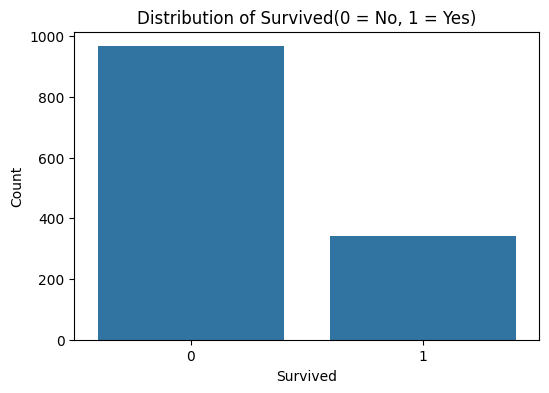

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df)
plt.title('Distribution of Survived(0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

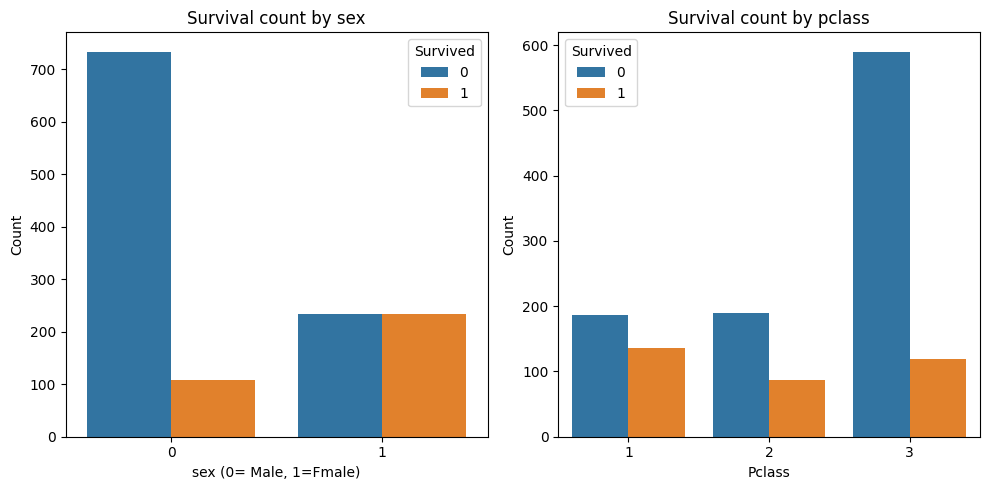

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival count by sex')
plt.xlabel('sex (0= Male, 1=Fmale)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='Pclass' , hue='Survived' , data=df)
plt.title('Survival count by pclass')
plt.xlabel('Pclass')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

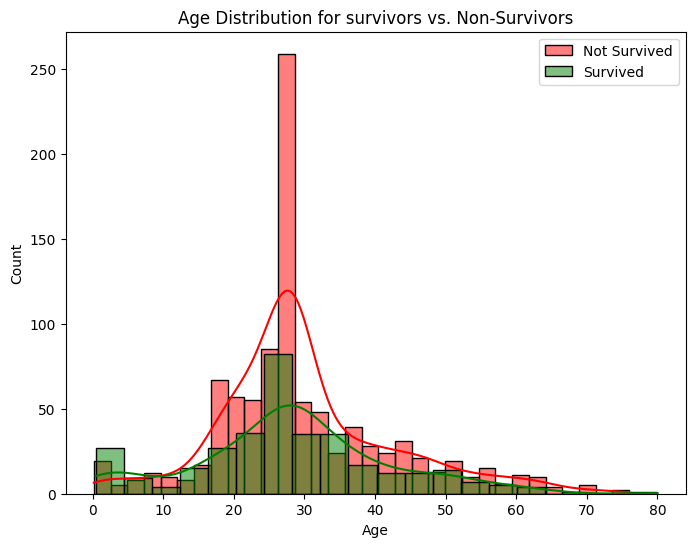

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df[df['Survived'] == 0]['Age'], color='red', label='Not Survived' , kde=True)
sns.histplot(df[df['Survived'] == 1]['Age'], color='green', label='Survived', kde=True)
plt.title('Age Distribution for survivors vs. Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df.drop('Survived' , axis=1)
y = df['Survived'] # Corrected: 'Surivived' to 'Survived'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Corrected: 'Y' to 'y'

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Corrected: 'fit_transfrom' to 'fit_transform'
X_test_scaled = scaler.transform(X_test) # Corrected: 'transfrom' to 'transform'

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:") # Corrected: '/n' to '\n'
print(confusion_matrix(y_test, y_pred)) # Corrected: 'y_pred=' to 'y_pred'
print("\nClassification Report:") # Corrected: '/n' to '\n'
print(classification_report(y_test, y_pred))

Accuracy: 0.77

Confusion Matrix:
[[174  15]
 [ 46  27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       189
           1       0.64      0.37      0.47        73

    accuracy                           0.77       262
   macro avg       0.72      0.65      0.66       262
weighted avg       0.75      0.77      0.74       262



#Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree Classifier
dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_dtree = dtree_model.predict(X_test_scaled)

# Evaluate the Decision Tree model
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dtree):.2f}")
print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dtree))
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dtree))

Decision Tree Accuracy: 0.71

Decision Tree Confusion Matrix:
[[149  40]
 [ 35  38]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       189
           1       0.49      0.52      0.50        73

    accuracy                           0.71       262
   macro avg       0.65      0.65      0.65       262
weighted avg       0.72      0.71      0.72       262



#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the Random Forest model
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.71

Random Forest Confusion Matrix:
[[150  39]
 [ 37  36]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       189
           1       0.48      0.49      0.49        73

    accuracy                           0.71       262
   macro avg       0.64      0.64      0.64       262
weighted avg       0.71      0.71      0.71       262



#Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

# Initialize and train the Support Vector Machine Classifier
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate the SVM model
print(f"Support Vector Machine Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print("\nSupport Vector Machine Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nSupport Vector Machine Classification Report:")
print(classification_report(y_test, y_pred_svm))

Support Vector Machine Accuracy: 0.79

Support Vector Machine Confusion Matrix:
[[176  13]
 [ 42  31]]

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.86       189
           1       0.70      0.42      0.53        73

    accuracy                           0.79       262
   macro avg       0.76      0.68      0.70       262
weighted avg       0.78      0.79      0.77       262



#K-Nearest Neighbors(KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the K-Nearest Neighbors Classifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate the KNN model
print(f"K-Nearest Neighbors Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print("\nK-Nearest Neighbors Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nK-Nearest Neighbors Classification Report:")
print(classification_report(y_test, y_pred_knn))

K-Nearest Neighbors Accuracy: 0.73

K-Nearest Neighbors Confusion Matrix:
[[161  28]
 [ 43  30]]

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       189
           1       0.52      0.41      0.46        73

    accuracy                           0.73       262
   macro avg       0.65      0.63      0.64       262
weighted avg       0.71      0.73      0.72       262



#Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize and train the Gaussian Naive Bayes Classifier
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_nb = nb_model.predict(X_test_scaled)

# Evaluate the Naive Bayes model
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb):.2f}")
print("\nNaive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.72

Naive Bayes Confusion Matrix:
[[168  21]
 [ 53  20]]

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.89      0.82       189
           1       0.49      0.27      0.35        73

    accuracy                           0.72       262
   macro avg       0.62      0.58      0.59       262
weighted avg       0.68      0.72      0.69       262

